# 02: Risk Forecasting Model
**Goal:** Forecast next-period volatility per asset and compare three approaches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from arch import arch_model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")
HORIZON = 5     
LOOKBACK = 20   

returns = pd.read_csv(PROCESSED_DIR / "log_returns.csv", index_col=0, parse_dates=True)
tickers = returns.columns.tolist()
returns.shape, returns.index.min(), returns.index.max()

((2924, 10),
 Timestamp('2015-01-05 00:00:00'),
 Timestamp('2026-08-20 00:00:00'))

## Forward realized volatility
$$ \text{target}_t = \text{std}(r_{t+1}, \dots, r_{t+5}) \times \sqrt{252} $$

In [2]:
target = returns.rolling(HORIZON).std().shift(-HORIZON) * np.sqrt(252)

t_idx = 25
manual = returns["SPY"].iloc[t_idx + 1: t_idx + 1 + HORIZON].std() * np.sqrt(252)
assert np.isclose(manual, target["SPY"].iloc[t_idx]), "target construction bug"
print("target construction verified, no look-ahead leakage")

target construction verified, no look-ahead leakage


## Walk-forward split

In [3]:
n = len(returns)
train_end = returns.index[int(n * 0.70)]
val_end = returns.index[int(n * 0.85)]

train_mask = returns.index <= train_end
val_mask = (returns.index > train_end) & (returns.index <= val_end)
test_mask = returns.index > val_end

print(f"train <= {train_end.date()} ({train_mask.sum()} rows)")
print(f"val   <= {val_end.date()} ({val_mask.sum()} rows)")
print(f"test  after {val_end.date()} ({test_mask.sum()} rows)")

train <= 2023-02-21 (2047 rows)
val   <= 2024-11-18 (439 rows)
test  after 2024-11-18 (438 rows)


In [4]:
def qlike(y_true, y_pred):
    """QLIKE loss on variances. Asymmetric: penalises under-forecasting of
    volatility more heavily than over-forecasting. Zero for a perfect forecast."""
    ratio = np.square(y_true) / np.clip(np.square(y_pred), 1e-12, None)
    ratio = np.clip(ratio, 1e-12, None)
    return np.mean(ratio - np.log(ratio) - 1)

def eval_method(name, forecast_df):
    """MSE, R2, MAE, QLIKE and mean bias on the test set, per asset,
    for a wide forecast dataframe."""
    rows = []
    for tkr in tickers:
        y_true = target[tkr][test_mask].dropna()
        y_pred = forecast_df[tkr].reindex(y_true.index).dropna()
        common = y_true.index.intersection(y_pred.index)
        yt, yp = y_true.loc[common], y_pred.loc[common]
        if len(yt) < 10:
            continue
        rows.append({
            "ticker": tkr, "method": name,
            "mse": mean_squared_error(yt, yp),
            "r2": r2_score(yt, yp),
            "mae": mean_absolute_error(yt, yp),
            "qlike": qlike(yt.values, yp.values),
            "bias": np.mean(yp.values - yt.values),
            "n": len(yt),
        })
    return pd.DataFrame(rows)

## Baseline A: rolling historical volatility
$$ \hat\sigma_{t+1:t+5} = \text{std}(r_{t-19}, \dots, r_t) \times \sqrt{252} $$

In [5]:
rolling_vol_forecast = returns.rolling(LOOKBACK).std() * np.sqrt(252)

baseline_a = eval_method("rolling_vol", rolling_vol_forecast)
baseline_a.set_index("ticker")[["mse", "r2", "mae", "qlike"]].round(4)

,mse,r2,mae,qlike
ticker,,,,
DBC,0.0076,-0.0429,0.0638,0.6332
EFA,0.0104,-0.2511,0.0658,0.5925
GLD,0.0191,-0.0364,0.0891,0.7239
HYG,0.0011,-0.1246,0.0198,0.7774
IEF,0.0004,-0.0308,0.0147,0.2549
IWM,0.0128,-0.2760,0.0790,0.4795
QQQ,0.0183,-0.1106,0.0856,0.7504
SPY,0.0140,-0.1660,0.0689,0.8512
TLT,0.0022,-0.1676,0.0355,0.3469


## Baseline B: GARCH(1,1)

$$ \sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2 $$

Refit every 21 trading days (roughly
monthly) on an expanding window rather than every single day, which keeps runtime
reasonable while still letting the model adapt as new data arrives, a standard practical
compromise in volatility-forecasting research.

In [6]:
REFIT_EVERY = 21

def garch_rolling_forecast(returns_series, test_start_pos, refit_every=REFIT_EVERY, horizon=HORIZON):
    r = returns_series * 100 
    n = len(r)
    forecast = pd.Series(index=returns_series.index, dtype=float)
    fit_positions = list(range(test_start_pos, n, refit_every))
    for i, start_pos in enumerate(fit_positions):
        end_pos = fit_positions[i + 1] if i + 1 < len(fit_positions) else n
        train_slice = r.iloc[:start_pos]
        if len(train_slice) < 250:
            continue
        try:
            am = arch_model(train_slice, vol="Garch", p=1, q=1, dist="normal", rescale=False)
            res = am.fit(disp="off", show_warning=False)
            fc = res.forecast(horizon=horizon, reindex=False)
            avg_var = fc.variance.values[-1].mean()
            ann_vol = np.sqrt(avg_var) / 100 * np.sqrt(252)
        except Exception:
            ann_vol = np.nan
        forecast.iloc[start_pos:end_pos] = ann_vol
    return forecast

test_start_pos = int(np.argmax(test_mask))
garch_forecasts = {tkr: garch_rolling_forecast(returns[tkr], test_start_pos) for tkr in tickers}
garch_forecast_df = pd.DataFrame(garch_forecasts)

baseline_b = eval_method("garch", garch_forecast_df)
baseline_b.set_index("ticker")[["mse", "r2", "mae", "qlike"]].round(4)

,mse,r2,mae,qlike
ticker,,,,
DBC,0.0078,-0.0662,0.0665,0.5377
EFA,0.0105,-0.2720,0.0703,0.7679
GLD,0.0195,-0.0592,0.0898,0.8619
HYG,0.0014,-0.3848,0.0260,0.9731
IEF,0.0004,0.0286,0.0147,0.2427
IWM,0.0125,-0.2501,0.0811,0.4617
QQQ,0.0195,-0.1845,0.0939,0.7128
SPY,0.0140,-0.1649,0.0758,0.7843
TLT,0.0021,-0.1389,0.0366,0.3130


## Model- LSTM
$$
f_t = S(W_f x_t + U_f h_{t-1} + b_f), \qquad
i_t = S(W_i x_t + U_i h_{t-1} + b_i), \qquad
\tilde c_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$
$$
c_t = f_t * c_{t-1} + i_t * \tilde c_t, \qquad
o_t = S(W_o x_t + U_o h_{t-1} + b_o), \qquad
h_t = o_t * \tanh(c_t)
$$

In [7]:
def build_sequences(returns_df, target_df, mask, lookback=LOOKBACK):
    roll5_df = returns_df.rolling(5).std() * np.sqrt(252)
    X, y, idx_ticker, idx_date = [], [], [], []
    for tkr in returns_df.columns:
        r = returns_df[tkr].values
        v = roll5_df[tkr].values
        t = target_df[tkr].values
        dates = returns_df.index
        for pos in np.where(mask)[0]:
            if pos - lookback < 0 or np.isnan(t[pos]):
                continue
            r_window, v_window = r[pos - lookback:pos], v[pos - lookback:pos]
            if np.isnan(r_window).any() or np.isnan(v_window).any():
                continue
            X.append(np.stack([r_window, v_window], axis=-1))
            y.append(t[pos])
            idx_ticker.append(tkr)
            idx_date.append(dates[pos])
    X = np.array(X, dtype=np.float32).reshape(-1, lookback, 2)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    return X, y, idx_ticker, idx_date

X_train, y_train, _, _ = build_sequences(returns, target, train_mask)
X_val, y_val, _, _ = build_sequences(returns, target, val_mask)
X_test, y_test, test_tickers, test_dates = build_sequences(returns, target, test_mask)
X_train.shape, X_val.shape, X_test.shape

((20230, 20, 2), (4390, 20, 2), (4330, 20, 2))

In [8]:
y_mean, y_std = y_train.mean(), y_train.std()
def scale_y(y): return (y - y_mean) / y_std
def unscale_y(y): return y * y_std + y_mean

Xtr, ytr = torch.tensor(X_train), torch.tensor(scale_y(y_train))
Xva, yva = torch.tensor(X_val), torch.tensor(scale_y(y_val))
Xte = torch.tensor(X_test)

class VolLSTM(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, (h, c) = self.lstm(x)
        return self.head(h[-1])

torch.manual_seed(42)
model = VolLSTM()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

best_val, best_state, patience, bad_epochs = float("inf"), None, 8, 0
batch_size = 256

for epoch in range(60):
    model.train()
    perm = torch.randperm(Xtr.shape[0])
    for i in range(0, len(perm), batch_size):
        idx = perm[i:i + batch_size]
        opt.zero_grad()
        loss = loss_fn(model(Xtr[idx]), ytr[idx])
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva), yva).item()

    if val_loss < best_val:
        best_val, best_state, bad_epochs = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        bad_epochs += 1
    if epoch % 5 == 0:
        print(f"epoch {epoch:3d}  val_loss={val_loss:.4f}")
    if bad_epochs >= patience:
        print("early stopping at epoch", epoch)
        break

model.load_state_dict(best_state)
model.eval()

epoch   0  val_loss=0.3518


epoch   5  val_loss=0.2722


epoch  10  val_loss=0.2805


epoch  15  val_loss=0.2708


epoch  20  val_loss=0.2679


epoch  25  val_loss=0.2942


epoch  30  val_loss=0.2623


epoch  35  val_loss=0.2657


early stopping at epoch 38


VolLSTM(
  (lstm): LSTM(2, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

In [9]:
with torch.no_grad():
    test_pred = unscale_y(model(Xte).numpy().flatten())

lstm_forecast_df = pd.DataFrame({"ticker": test_tickers, "date": test_dates, "pred": test_pred})
lstm_pivot = lstm_forecast_df.pivot(index="date", columns="ticker", values="pred")

baseline_c = eval_method("lstm", lstm_pivot)
baseline_c.set_index("ticker")[["mse", "r2", "mae", "qlike"]].round(4)

,mse,r2,mae,qlike
ticker,,,,
DBC,0.0077,-0.0500,0.0613,0.6806
EFA,0.0081,0.0201,0.0572,0.5699
GLD,0.0184,-0.0024,0.0786,0.9767
HYG,0.0012,-0.2258,0.0263,0.7053
IEF,0.0006,-0.6251,0.0204,0.3050
IWM,0.0097,0.0272,0.0655,0.5006
QQQ,0.0137,0.1691,0.0716,0.7768
SPY,0.0099,0.1794,0.0563,0.7280
TLT,0.0020,-0.0798,0.0350,0.3052


## Comparison

                mse      r2     mae   qlike    bias
method                                             
rolling_vol  0.0094 -0.1497  0.0584  0.5978  0.0090
garch        0.0095 -0.1738  0.0619  0.6150  0.0149
lstm         0.0078 -0.0596  0.0528  0.6067 -0.0003


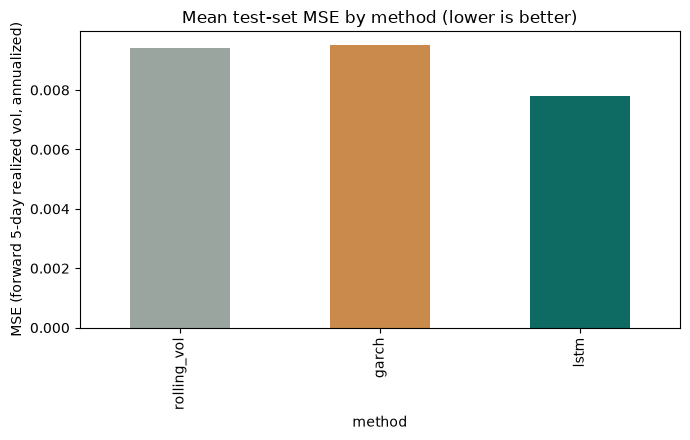

In [10]:
summary = pd.concat([baseline_a, baseline_b, baseline_c])
comparison = summary.groupby("method")[["mse", "r2", "mae", "qlike", "bias"]].mean().round(4)
comparison = comparison.reindex(["rolling_vol", "garch", "lstm"])
print(comparison)

fig, ax = plt.subplots(figsize=(7, 4.5))
comparison["mse"].plot(kind="bar", ax=ax, color=["#9aa5a0", "#c98a4b", "#0e6b64"])
ax.set_title("Mean test-set MSE by method (lower is better)")
ax.set_ylabel("MSE (forward 5-day realized vol, annualized)")
plt.tight_layout()
plt.show()

In [11]:
lstm_pivot.to_csv(PROCESSED_DIR / "lstm_vol_forecast.csv")
rolling_vol_forecast.to_csv(PROCESSED_DIR / "rolling_vol_forecast.csv")
garch_forecast_df.to_csv(PROCESSED_DIR / "garch_vol_forecast.csv")
comparison.to_csv(PROCESSED_DIR / "risk_model_comparison.csv")
torch.save(model.state_dict(), PROCESSED_DIR / "lstm_vol_model.pt")

import json
with open(PROCESSED_DIR / "lstm_vol_scaler.json", "w") as f:
    json.dump({"y_mean": float(y_mean), "y_std": float(y_std)}, f)

train_corr = returns[train_mask].corr()
train_corr.to_csv(PROCESSED_DIR / "historical_correlation.csv")

print("Saved: lstm_vol_forecast.csv, rolling_vol_forecast.csv, garch_vol_forecast.csv,")
print("       risk_model_comparison.csv, lstm_vol_model.pt, lstm_vol_scaler.json,")
print("       historical_correlation.csv")

Saved: lstm_vol_forecast.csv, rolling_vol_forecast.csv, garch_vol_forecast.csv,
       risk_model_comparison.csv, lstm_vol_model.pt, lstm_vol_scaler.json,
       historical_correlation.csv
